# Project 01 - Urban Flood Risk & Vulnerability Mapping

## 1. Download & Load the Data

### 1.1 - Set Up Imports and Configuration

In [ ]:
# Install all required libraries
!pip install geopandas folium esda libpysal scikit-learn matplotlib
!pip install contextily osmnx censusdatadownloader shapely pysal

# ── Verify installations ───────────────────────────────────────────────────
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
import esda
import libpysal
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
print('All libraries loaded successfully!')

  Using cached contextily-1.7.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached osmnx-2.1.0-py3-none-any.whl.metadata (4.7 kB)
ERROR: Could not find a version that satisfies the requirement censusdatadownloader (from versions: none)
ERROR: No matching distribution found for censusdatadownloader
All libraries loaded successfully!


### 1.2 - Download FEMA Flood Zone Data

In [ ]:
# ── Standard imports ──────────────────────────────────────────────────────
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
from folium.plugins import FloatImage
import requests, zipfile, io, os
import warnings
warnings.filterwarnings('ignore')
# ── Project configuration ─────────────────────────────────────────────────
# Harris County FIPS code (Texas = 48, Harris County = 201)
STATE_FIPS = '48'
COUNTY_FIPS = '201'
COUNTY_NAME = 'Harris County, TX'
# We'll work in this Coordinate Reference System (CRS)
# EPSG:32615 = UTM Zone 15N — best for Houston area (units: meters)
PROJ_CRS = 'EPSG:32615'
print(f'Project: Flood Vulnerability — {COUNTY_NAME}')

Project: Flood Vulnerability — Harris County, TX


In [ ]:
# def download_fema_flood_zones(state_fips, county_fips):
#     """
#     Downloads FEMA NFHL flood zone polygons for a specific county.
#     Returns a GeoDataFrame with flood zone designations.
#     """

#     # FEMA NFHL REST API endpoint for Flood Zone polygons (Layer 28)
#     base_url = ('https://hazards.fema.gov/arcgis/rest/services/'
#                 'public/NFHL/MapServer/28/query')

#     # Build query: filter to Harris County by FIPS code
#     params = {
#         'where': f"DFIRM_ID LIKE '{STATE_FIPS}{COUNTY_FIPS}%'",
#         'outFields': 'FLD_ZONE,ZONE_SUBTY,STUDY_TYP',
#         'f': 'geojson', # Request GeoJSON format
#         'returnGeometry': 'true',
#         'resultRecordCount': 4000, # Request only 1 record for debugging
#         'outSR': '4326', # Output Spatial Reference: WGS 84
#     }

#     response = requests.get(base_url, params=params, timeout=300)
#     gdf = gpd.read_file(io.StringIO(response.text))
#     gdf = gdf.to_crs(PROJ_CRS) # Reproject to meters

#     print(f'Downloaded {len(gdf):,} flood zone polygons')
#     print(f'Unique flood zone types: {gdf["FLD_ZONE"].unique()}')
#     return gdf

# flood_zones = download_fema_flood_zones(STATE_FIPS, COUNTY_FIPS)
# flood_zones.head(3)

In [ ]:
def download_fema_flood_zones(state_fips, county_fips):
    print('🔄 Downloading FEMA flood zone data...')

    # ArcGIS Online hosted NFHL — more reliable than hazards.fema.gov direct
    base_url = ('https://services.arcgis.com/P3ePLMYs2RVChkJx/arcgis/rest/'
                'services/USA_Flood_Hazard_Reduced_Set_gdb/FeatureServer/0/query')

    params = {
        'where': f"DFIRM_ID LIKE '{county_fips}%'",
        'outFields': 'FLD_ZONE,ZONE_SUBTY,STUDY_TYP',
        'f': 'geojson',
        'returnGeometry': 'true',
        'resultRecordCount': 4000,
        'outSR': '4326',
    }

    response = requests.get(base_url, params=params, timeout=120)

    if response.status_code != 200:
        raise requests.exceptions.RequestException(
            f"Failed to download FEMA data. Status code: {response.status_code}"
        )

    gdf = gpd.read_file(io.StringIO(response.text))
    gdf = gdf.to_crs(PROJ_CRS)

    print(f'   ✅ Downloaded {len(gdf):,} flood zone polygons')
    print(f'   Unique flood zone types: {gdf["FLD_ZONE"].unique()}')
    return gdf

flood_zones = download_fema_flood_zones(STATE_FIPS, COUNTY_FIPS)
flood_zones.head(3)

🔄 Downloading FEMA flood zone data...
   ✅ Downloaded 2,000 flood zone polygons
   Unique flood zone types: ['X' 'AE' 'AH' 'A']


,FLD_ZONE,ZONE_SUBTY,STUDY_TYP,geometry
0,X,0.2 Percent Annual Chance Flood Hazard,SFHAs With Medium Flood Risk,"POLYGON ((241873.269 4273312.864, 241870.919 4..."
1,X,0.2 Percent Annual Chance Flood Hazard,SFHAs With Medium Flood Risk,"POLYGON ((257396.687 4295629.048, 257394.062 4..."
2,X,Area With Reduced Flood Risk Due To Levee,SFHAs With High Flood Risk,"POLYGON ((70576.829 4222733.693, 70580.105 422..."


In [ ]:
display(flood_zones.head(20))

,FLD_ZONE,ZONE_SUBTY,STUDY_TYP,geometry
0,X,0.2 Percent Annual Chance Flood Hazard,SFHAs With Medium Flood Risk,"POLYGON ((241873.269 4273312.864, 241870.919 4..."
1,X,0.2 Percent Annual Chance Flood Hazard,SFHAs With Medium Flood Risk,"POLYGON ((257396.687 4295629.048, 257394.062 4..."
2,X,Area With Reduced Flood Risk Due To Levee,SFHAs With High Flood Risk,"POLYGON ((70576.829 4222733.693, 70580.105 422..."
3,X,0.2 Percent Annual Chance Flood Hazard,SFHAs With Medium Flood Risk,"POLYGON ((214476.76 4248902.555, 214474.059 42..."
4,X,0.2 Percent Annual Chance Flood Hazard,SFHAs With Low Flood Risk,"POLYGON ((227295.444 4347213.824, 227295.512 4..."
5,X,0.2 Percent Annual Chance Flood Hazard,SFHAs With Low Flood Risk,"POLYGON ((206424.005 4303862.715, 206423.193 4..."
6,X,0.2 Percent Annual Chance Flood Hazard,SFHAs With High Flood Risk,"POLYGON ((71634.006 4219077.893, 71628.951 421..."
7,X,0.2 Percent Annual Chance Flood Hazard,SFHAs With Medium Flood Risk,"POLYGON ((212003.029 4269464.889, 212002.615 4..."
8,X,0.2 Percent Annual Chance Flood Hazard,Sfha With Unpublished Bfe,"POLYGON ((88331.802 4352703.036, 88330.305 435..."
9,X,0.2 Percent Annual Chance Flood Hazard,Sfha With Unpublished Bfe,"POLYGON ((150820.986 4244400.602, 150820.533 4..."


### 1.3 - Download Census Tract Boundaries with Demographics

In [ ]:
# def download_census_tracts(state_fips, county_fips):
#   """
#   Downloads census tract boundaires + ACS demographic variables
#   for the target county. Returns a GeoDataFrame.
#   """

#   # ── Step 1: Get tract geometries from Census TIGER API ───────────────
#   geo_url = ('https://tigerweb.geo.census.gov/arcgis/rest/services/'
#               'TIGERweb/Tracts_Blocks/MapServer/6/query')
#   geo_params = {
#       'where': f"STATE='{state_fips}' AND COUNTY='{county_fips}'",
#       'outFields': 'GEOID,NAME',
#       'f': 'geojson',
#       'returnGeometry': 'true',
#       'outSR': '4326',
#   }
#   resp = requests.get(geo_url, params=geo_params, timeout=120)
#   tracts = gpd.read_file(io.BytesIO(resp.content))
#   tracts = tracts.to_crs(PROJ_CRS)

#   # ── Step 2: Get ACS 5-year demographic data ─────────────────────────
#   # Variables: B01003_001E = total pop, B19013_001E = median income,
#   #            B17001_002E = below poverty, B25002_003E = vacant units
#   acs_url = 'https://api.census.gov/data/2021/acs/acs5'
#   variables = 'B01003_001E,B19013_001E,B17001_002E,B25002_003E'
#   acs_params = {
#       'get': variables,
#       'for': f'tract:*',
#       'in': f'state:{state_fips} county:{county_fips}',
#   }
#   acs_resp = requests.get(acs_url, params=acs_params)
#   acs_data = acs_resp.json()
#   acs_df = pd.DataFrame(acs_data[1:], columns=acs_data[0])
#   acs_df['GEOID'] = acs_df['state'] + acs_df['county'] + acs_df['tract']

#   # Rename columns to meaningful names
#   acs_df = acs_df.rename(columns={
#       'B01003_001E': 'total_pop',
#       'B19013_001E': 'median_income',
#       'B17001_002E': 'poverty_count',
#       'B25002_003E': 'vacant_units',
#   })
#   # Convert to numeric (census API returns strings)
#   for col in ['total_pop','median_income','poverty_count','vacant_units']:
#       acs_df[col] = pd.to_numeric(acs_df[col], errors='coerce')
#   acs_df['poverty_rate'] = acs_df['poverty_count'] / acs_df['total_pop']

#   # ── Step 3: Merge geometry + demographics ────────────────────────────
#   tracts = tracts.merge(acs_df[['GEOID','total_pop','median_income',
#                                   'poverty_rate','vacant_units']],
#                         on='GEOID', how='left')
#   print(f'Loaded {len(tracts)} census tracts')
#   print(f'Columns: {list(tracts.columns)}')
#   return tracts

# tracts = download_census_tracts(STATE_FIPS, COUNTY_FIPS)

In [ ]:
# tracts = download_census_tracts(STATE_FIPS, COUNTY_FIPS)

# # ── Diagnose the GEOID mismatch ──────────────────────────────────────
# # Re-run the ACS fetch manually to inspect both sides
# acs_url = 'https://api.census.gov/data/2021/acs/acs5'
# acs_params = {
#     'get': 'B01003_001E,B19013_001E,B17001_002E,B25002_003E',
#     'for': 'tract:*',
#     'in': f'state:{STATE_FIPS} county:{COUNTY_FIPS}',
# }
# acs_resp = requests.get(acs_url, params=acs_params)
# acs_data = acs_resp.json()
# acs_df = pd.DataFrame(acs_data[1:], columns=acs_data[0])
# acs_df['GEOID'] = acs_df['state'] + acs_df['county'] + acs_df['tract']

# print("TIGER GEOID samples: ", tracts['GEOID'].head(3).tolist())
# print("ACS   GEOID samples: ", acs_df['GEOID'].head(3).tolist())
# print("TIGER GEOID dtype:   ", tracts['GEOID'].dtype)
# print("ACS   GEOID dtype:   ", acs_df['GEOID'].dtype)
# print("Any matches?         ", tracts['GEOID'].isin(acs_df['GEOID']).sum())

In [ ]:
def download_census_tracts(state_fips, county_fips):
    """
    Downloads census tract boundaries + ACS demographic variables.
    Uses Census cartographic boundary shapefile (more reliable than TIGER REST).
    """

    # ── Step 1: Get tract geometries from Census cartographic boundary file ──
    # Direct shapefile download — always has correct 11-digit GEOIDs
    # Format: cb_{year}_{state_fips}_tract_{resolution}.zip
    shp_url = (f'https://www2.census.gov/geo/tiger/GENZ2021/shp/'
               f'cb_2021_{state_fips}_tract_500k.zip')

    print('   Downloading shapefile...')
    resp = requests.get(shp_url, timeout=120)
    if resp.status_code != 200:
        raise Exception(f'Shapefile download failed: {resp.status_code}')

    # Read directly from zip bytes in memory — pass the full zip, not just the .shp
    import zipfile
    import tempfile
    import os

    # Write zip to a temp directory so geopandas can access all companion files
    with tempfile.TemporaryDirectory() as tmpdir:
        zip_path = os.path.join(tmpdir, 'tracts.zip')
        with open(zip_path, 'wb') as f:
            f.write(resp.content)
        # GeoPandas can read directly from a zip path using this syntax
        tracts = gpd.read_file(f'zip://{zip_path}')

    # Filter to our county — COUNTYFP is the 3-digit county code
    tracts = tracts[tracts['COUNTYFP'] == county_fips].copy()
    tracts = tracts.to_crs(PROJ_CRS)

    # Sanity check — Harris County should have ~786 tracts
    print(f'   Tract count: {len(tracts)} (expected ~786 for Harris County)')
    print(f'   Sample GEOID: {tracts["GEOID"].iloc[0]} (should be 11 digits)')

    # ── Step 2: ACS demographics (unchanged) ────────────────────────────────
    acs_url = 'https://api.census.gov/data/2021/acs/acs5'
    acs_params = {
        'get': 'B01003_001E,B19013_001E,B17001_002E,B25002_003E',
        'for': 'tract:*',
        'in': f'state:{state_fips} county:{county_fips}',
    }
    acs_resp = requests.get(acs_url, params=acs_params, timeout=60)
    acs_data = acs_resp.json()
    acs_df = pd.DataFrame(acs_data[1:], columns=acs_data[0])
    acs_df['GEOID'] = acs_df['state'] + acs_df['county'] + acs_df['tract']

    acs_df = acs_df.rename(columns={
        'B01003_001E': 'total_pop',
        'B19013_001E': 'median_income',
        'B17001_002E': 'poverty_count',
        'B25002_003E': 'vacant_units',
    })
    for col in ['total_pop', 'median_income', 'poverty_count', 'vacant_units']:
        acs_df[col] = pd.to_numeric(acs_df[col], errors='coerce')
    acs_df['poverty_rate'] = acs_df['poverty_count'] / acs_df['total_pop']

    # ── Step 3: Merge ────────────────────────────────────────────────────────
    tracts = tracts.merge(
        acs_df[['GEOID', 'total_pop', 'median_income', 'poverty_rate', 'vacant_units']],
        on='GEOID', how='left'
    )

    matched = tracts['total_pop'].notna().sum()
    print(f'Loaded {len(tracts)} census tracts ({matched} matched with ACS data)')
    return tracts

tracts = download_census_tracts(STATE_FIPS, COUNTY_FIPS)

   Tract count: 1115 (expected ~786 for Harris County)
   Sample GEOID: 48201331501 (should be 11 digits)
Loaded 1115 census tracts (1115 matched with ACS data)


### 1.4 - Download Water Bodies via OpenStreetMap

In [ ]:
!pip install osmnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 6.5 MB/s eta 0:00:00


In [ ]:
import osmnx as ox

def download_water_bodies(county_name):
  """
  Downlaods rivers, streams, and lakes from OpenStreetMap.
  Returns a GeoDataFrame of water body geometries.
  """

  # OSMnx 'features' method fetches OpenStreetMap tagged features
  # 'waterway' captures rivers and streams (line geometries)
  waterways = ox.features_from_place(
      county_name,
      tags={'waterway': ['river', 'stream', 'canal', 'drain']}
  )
  waterways = waterways[['geometry']].reset_index(drop=True)
  waterways = waterways.to_crs(PROJ_CRS)

  print(f'Downloaded {len(waterways):,} waterway features')
  return waterways

# Note: OSMnx uses place name as a string for geocoding
waterways = download_water_bodies('Harris County, Texas, USA')


Downloaded 5,575 waterway features


### 1.5 - Visualize the Raw Data

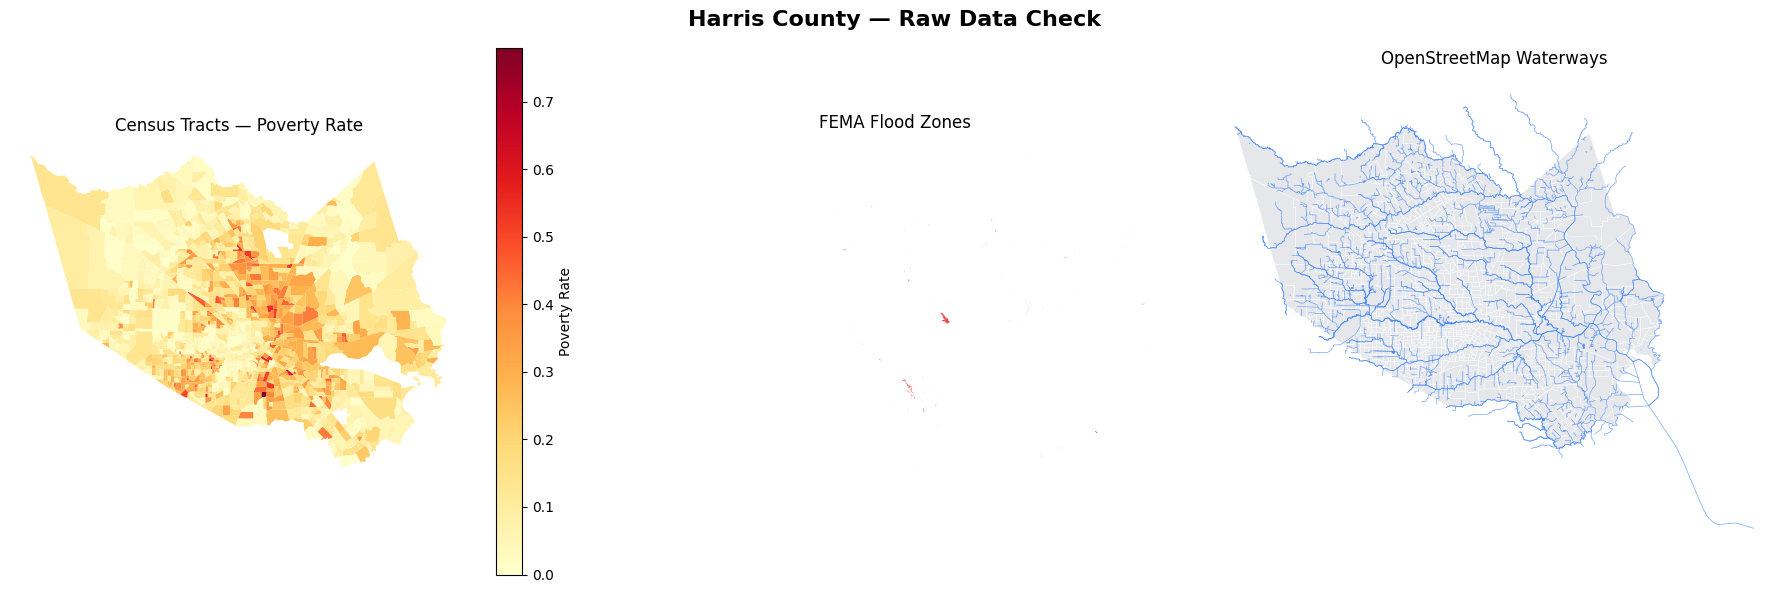

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Harris County — Raw Data Check', fontsize=16, fontweight='bold')

# Plot 1: Census tracts colored by poverty rate
tracts.plot(ax=axes[0], column='poverty_rate', cmap='YlOrRd',
            legend=True, legend_kwds={'label': 'Poverty Rate'})
axes[0].set_title('Census Tracts — Poverty Rate')
axes[0].axis('off')

# Plot 2: FEMA flood zones
zone_colors = {'AE':'#ef4444','AO':'#f97316','X':'#3b82f6','D':'#9ca3af'}
flood_zones['color'] = flood_zones['FLD_ZONE'].map(zone_colors).fillna('#e5e7eb')
flood_zones.plot(ax=axes[1], color=flood_zones['color'])
axes[1].set_title('FEMA Flood Zones')
axes[1].axis('off')

# Plot 3: Waterways
tracts.plot(ax=axes[2], color='#e5e7eb', edgecolor='white', linewidth=0.3)
waterways.plot(ax=axes[2], color='#3b82f6', linewidth=0.5, alpha=0.7)
axes[2].set_title('OpenStreetMap Waterways')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('01_raw_data_check.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Exploratory Data Analysis

### 2.1 - Check for Missing Values

In [ ]:
print('=== MISSING VALUE REPORT ===')
print()

# Check census tracts
print('--- Census Tracts ---')
missing = tracts[['total_pop','median_income','poverty_rate','vacant_units']].isnull().sum()
print(missing)
print(f'Total tracts: {len(tracts)}')
print()

# Check for tracts with very low population (hard to analyze)
low_pop = tracts[tracts['total_pop'] < 50]
print(f'Tracts with population < 50 (will be excluded): {len(low_pop)}')

# Drop missing and low-population tracts
tracts_clean = tracts.dropna(subset=['total_pop','median_income','poverty_rate'])
tracts_clean = tracts_clean[tracts_clean['total_pop'] >= 50].copy()
print(f'\nClean tracts remaining: {len(tracts_clean)}')

=== MISSING VALUE REPORT ===

--- Census Tracts ---
total_pop        0
median_income    0
poverty_rate     4
vacant_units     0
dtype: int64
Total tracts: 1115

Tracts with population < 50 (will be excluded): 5

Clean tracts remaining: 1110


### 2.2 - Understand the Distribution of Key Variables

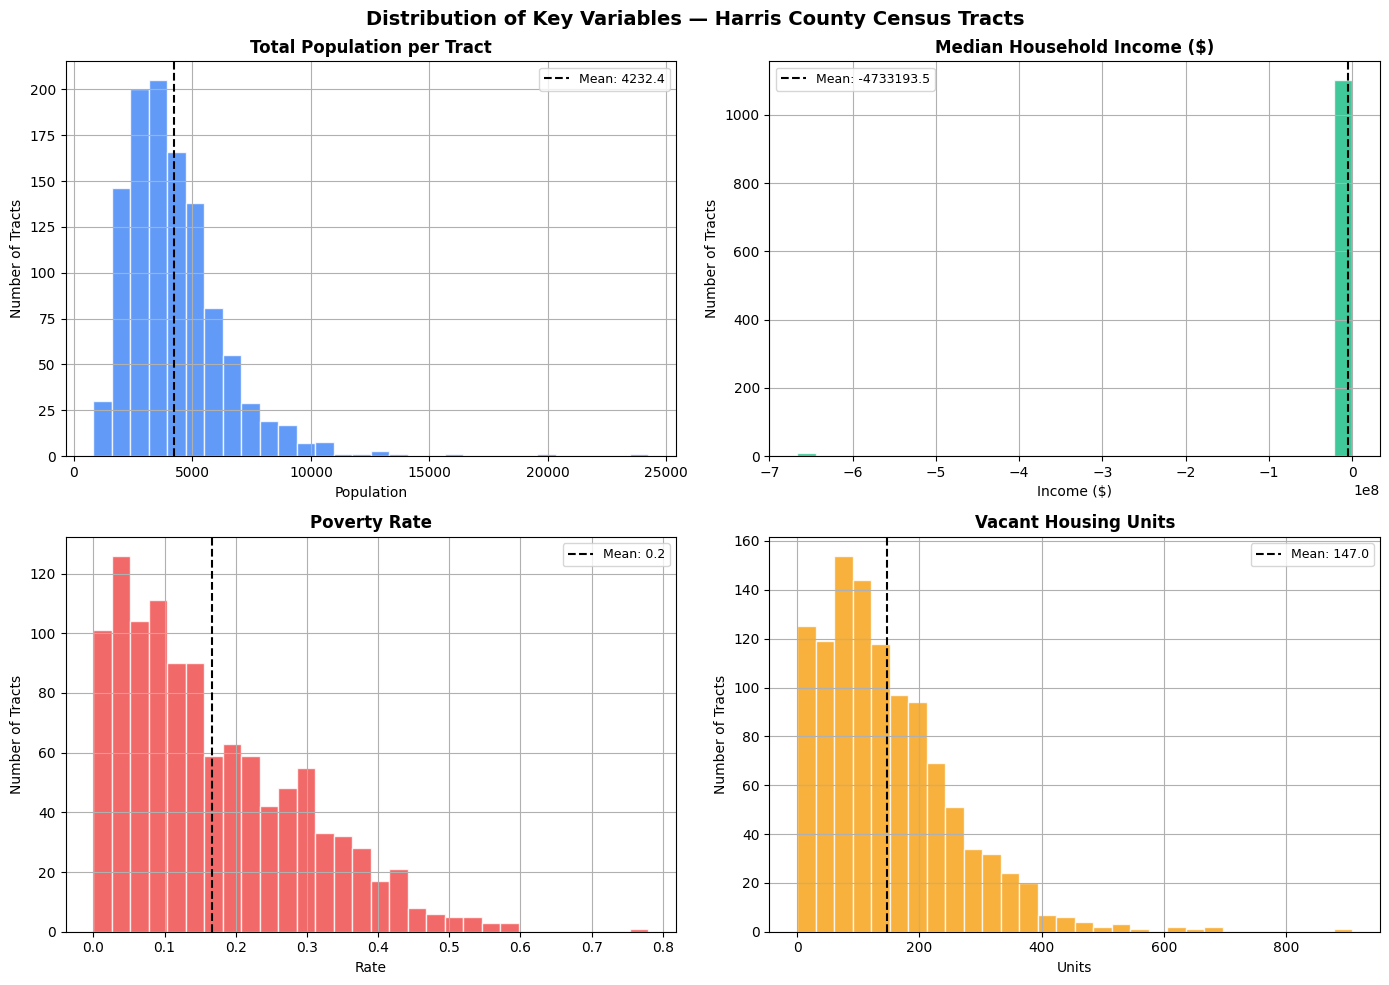

--- Summary Statistics ---
       total_pop  median_income  poverty_rate
count    1110.00   1.110000e+03       1110.00
mean     4232.38  -4.733193e+06          0.17
std      2096.90   5.642406e+07          0.13
min       821.00  -6.666667e+08          0.00
25%      2781.25   4.264125e+04          0.06
50%      3844.00   6.173750e+04          0.14
75%      5183.25   8.901525e+04          0.25
max     24245.00   2.500010e+05          0.78


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Variables — Harris County Census Tracts',
             fontsize=14, fontweight='bold')

plot_configs = [
    ('total_pop',     'Total Population per Tract',  'Population', '#3b82f6'),
    ('median_income', 'Median Household Income ($)', 'Income ($)',  '#10b981'),
    ('poverty_rate',  'Poverty Rate',                'Rate',        '#ef4444'),
    ('vacant_units',  'Vacant Housing Units',        'Units',       '#f59e0b'),
]

for ax, (col, title, xlabel, color) in zip(axes.flatten(), plot_configs):
    tracts_clean[col].hist(ax=ax, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Number of Tracts')
    # Add a vertical line at the mean
    ax.axvline(tracts_clean[col].mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: {tracts_clean[col].mean():.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('--- Summary Statistics ---')
print(tracts_clean[['total_pop','median_income','poverty_rate']].describe().round(2))

## 3. Engineer Spatial Features

### 3.1 - FEMA Flood Zone Coverage (Spatial Intersection)

In [ ]:
def calculate_flood_zone_coverage(tracts, flood_zones):
    """
    For each census tract, calculates the fraction of its area
    that overlaps with high-risk FEMA flood zones (AE, AO, VE).
    """

    # Filter to high-risk zones only
    high_risk = flood_zones[flood_zones['FLD_ZONE'].isin(['AE','AO','VE','A'])].copy()

    # Dissolve all high-risk zones into one single polygon
    # (so we can do one clean intersection)
    high_risk_dissolved = high_risk.dissolve()

    # Calculate each tract's total area (in square meters)
    tracts = tracts.copy()
    tracts['tract_area_m2'] = tracts.geometry.area

    # Compute the intersection of each tract with the high-risk zone polygon
    # This gives us the portion of the tract that is in a flood zone
    intersection = gpd.overlay(tracts[['GEOID','geometry','tract_area_m2']],
                               high_risk_dissolved[['geometry']],
                               how='intersection')

    # Calculate the flooded area for each tract
    intersection['flood_area_m2'] = intersection.geometry.area
    flood_coverage = intersection.groupby('GEOID')['flood_area_m2'].sum().reset_index()

    # Merge back and calculate the ratio (0 = no flood zone, 1 = entirely in zone)
    tracts = tracts.merge(flood_coverage, on='GEOID', how='left')
    tracts['flood_area_m2'] = tracts['flood_area_m2'].fillna(0)
    tracts['fema_flood_pct'] = tracts['flood_area_m2'] / tracts['tract_area_m2']
    tracts['fema_flood_pct'] = tracts['fema_flood_pct'].clip(0, 1)  # Cap at 100%

    print(f'Mean coverage: {tracts["fema_flood_pct"].mean():.1%}')
    print(f'Tracts > 50% in flood zone: {(tracts["fema_flood_pct"]>0.5).sum()}')
    return tracts

tracts_clean = calculate_flood_zone_coverage(tracts_clean, flood_zones)


Mean coverage: 0.0%
Tracts > 50% in flood zone: 0


### 3.2 - Distance to Nearest Waterway (Buffer / Proximity)

In [ ]:
def calculate_waterway_proximity(tracts, waterways):
    """
    For each census tract centroid, calculates the distance (in meters)
    to the nearest OSM waterway feature.
    """
    # Get the centroid of each tract (the geographic center point)
    tracts = tracts.copy()
    tract_centroids = tracts.geometry.centroid

    # Combine all waterway geometries into one union for efficient distance calc
    waterways_union = waterways.geometry.unary_union

    # Calculate distance from each tract centroid to the nearest waterway
    # .distance() returns distance in the CRS units — for EPSG:32615, that's meters
    tracts['dist_to_water_m'] = tract_centroids.distance(waterways_union)

    # Log-transform the distance: a tract 100m away vs 200m away matters more
    # than one 5,000m away vs 5,100m away. Log captures this diminishing effect.
    tracts['log_dist_to_water'] = np.log1p(tracts['dist_to_water_m'])

    print(f'Min distance: {tracts["dist_to_water_m"].min():.0f}m')
    print(f'Max distance: {tracts["dist_to_water_m"].max():.0f}m')
    print(f'Mean distance: {tracts["dist_to_water_m"].mean():.0f}m')
    return tracts

tracts_clean = calculate_waterway_proximity(tracts_clean, waterways)


Min distance: 0m
Max distance: 2843m
Mean distance: 618m


## 3.3 - Count Waterways within 1 km (Spatial Join with Buffer)

In [ ]:
def count_waterways_in_buffer(tracts, waterways, buffer_m=1000):
  """
  Creates a buffer around each tract centroid and counts how
  many waterway features intersect that buffer zone.
  buffer_m: buffer radius in meters (default 1km = 1000m)
  """

  tracts = tracts.copy()

  # Create a 1km buffer circle around each tract centroid
  tract_buffers = tracts.copy()
  tract_buffers['geometry'] = tracts.geometry.centroid.buffer(buffer_m)

  # Spatial join: find which waterways fall inside each buffer
  # how='left' means: keep all tracts even if no waterways found
  # predicate='intersects' means: waterway touches or overlaps the buffer
  joined = gpd.sjoin(
      tract_buffers[['GEOID', 'geometry']],
      waterways.reset_index()[['geometry']],
      how='left',
      predicate='intersects'
  )

  # Count how many waterways features each tract intersected
  waterway_counts = joined.groupby('GEOID').size().reset_index(
      name='waterways_within_1km'
  )

  tracts = tracts.merge(waterway_counts, on='GEOID', how='left')
  tracts['waterways_within_1km'] = tracts['waterways_within_1km'].fillna(0)

  print(f"Mean waterway count: {tracts['waterways_within_1km'].mean():.1f}")
  return tracts

tracts_clean = count_waterways_in_buffer(tracts_clean, waterways, buffer_m=1000)


Mean waterway count: 5.5


### 3.4 - Create the Target Variable (Composite Vulnerability Score)

In [ ]:
def create_vulnerability(tracts):
  """
  Creates a composite flood vulnerability score (0-100) for each
  census tract using a weighted combination of spatial + socioeconomic
  risk factors.

  Score formula (domain-knowledge weights):
    40% - FEMA flood zone coverage (physical hazard exposure)
    25% - Proximity to water (normalized, inverted: closer = higher risk)
    15% - Poverty rate (social vulnerability: less ability to recover)
    20% - Waterway density within 1 km (compund exposure risk)
  """
  tracts = tracts.copy()

  # Normalize each feature to 0-1 range using Min-Max scaling
  def minmax(series):
    return (series - series.min()) / (series.max() - series.min() +1e-9)

  # Physical hazard: FEMA coverage (higher = worse, already 0-1)
  fema_score = tracts['fema_flood_pct']

  # Proximity: INVERT so closer to water = higher score
  max_dist = tracts['dist_to_water_m'].max()
  proximity_score = 1 - minmax(tracts['dist_to_water_m'])

  # Social vulnerability: poverty rate (normalized)
  poverty_score = minmax(tracts['poverty_rate'])

  # Waterway density (normalized)
  density_score = minmax(tracts['waterways_within_1km'])

  # Composite weighted score (0-100)
  tracts['vulnerability_score'] = (
      0.4 * fema_score +
      0.25 * proximity_score +
      0.15 * poverty_score +
      0.2 * density_score
  ) * 100

  # Assign risk tiers for labeling
  tracts['risk_tier'] = pd.cut(
      tracts['vulnerability_score'],
      bins=[0, 20, 40, 60, 80, 100],
      labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
  )

  print(tracts['risk_tier'].value_counts())
  return tracts

tracts_clean = create_vulnerability(tracts_clean)

risk_tier
Low          872
Very Low     235
Medium         3
High           0
Very High      0
Name: count, dtype: int64


## 4. Spatial Autocorrelation Analysis

### 4.1 - Compute Global moran's I


In [ ]:
import esda
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

# Step 1: Build a spatial weights matrix
# The weights matrix defines which tracts are 'neighbors' of each other.
# Queen contiguity: two tracts are neighbors if they share any boundary point
# (includes corner-touching, unlike Rook which requires shared edges).

w = Queen.from_dataframe(tracts_clean, use_index=False)
w.transform = 'R'   # Row-standardize: Each row sums to 1
print(f'Weights matrix built: {w.n} tracts, mean neighbors: {w.mean_neighbors}')

# Step 2: Compute Global Moran's I
y = tracts_clean['vulnerability_score'].values
moran_global = Moran(y, w)

print('=== Global Moran\'s I Results ===')
print(f'Moran\'s I statistic: {moran_global.I:.4f}')
print(f'Expected value (HO): {moran_global.EI:.4f} (random = 0)')
print(f'P-value: {moran_global.p_sim:.4f}')

if moran_global.p_sim < 0.05:
    print('Statistically significant clustering detected (p < 0.05)')
    print(f'Interpretation: High-vulnerability tracts cluster tgether.')
    print(f'This confirms spatial autocorrelation - geogrpahy matters.')
else:
  print('No statistically significant clustering detected.')

Weights matrix built: 1110 tracts, mean neighbors: 6.535135135135135
=== Global Moran's I Results ===
Moran's I statistic: 0.4291
Expected value (HO): -0.0009 (random = 0)
P-value: 0.0010
Statistically significant clustering detected (p < 0.05)
Interpretation: High-vulnerability tracts cluster tgether.
This confirms spatial autocorrelation - geogrpahy matters.


### 4.2 - Local Moran's (LISA Map) - Findign the Hotspots

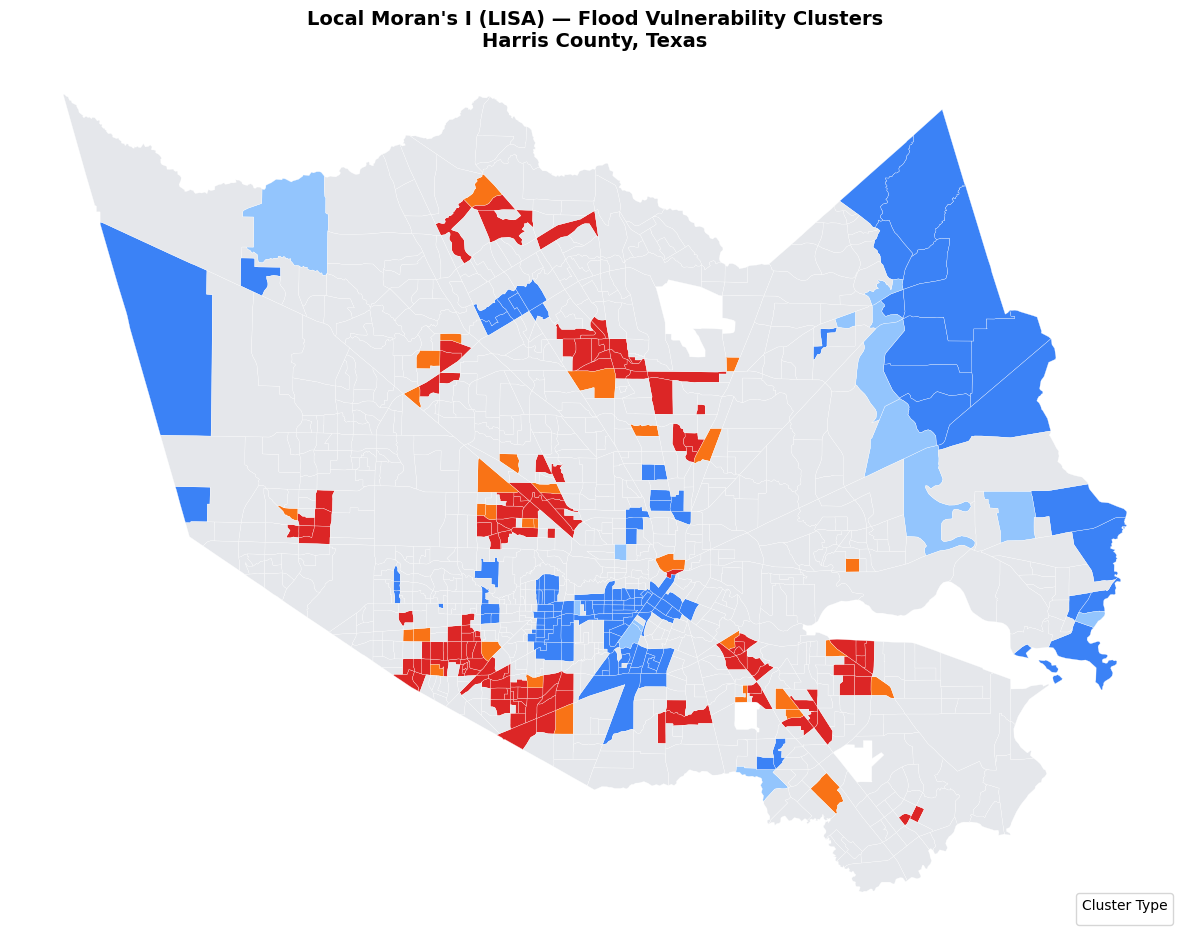


LISA cluster summary:
lisa_label
Not Significant    803
HH (Hotspot)       137
LL (Coldspot)      125
LH (Outlier)        31
HL (Outlier)        14
Name: count, dtype: int64


In [ ]:
# Compute Local Moran's I
moran_local = Moran_Local(y, w, permutations=999)

# Add LISA results to our GeoDataFrame
tracts_clean = tracts_clean.copy()
tracts_clean['lisa_I'] = moran_local.Is     # Local I statistic
tracts_clean['lisa_p'] = moran_local.p_sim  # Simulated p-value
tracts_clean['lisa_q'] = moran_local.q      # Quadrant classification

# Classify into standard LISA quadrant labels
# Quadrant codes: 1=HH, 2=LH, 3=LL, 4=HL
# HH = High vulnerability surrounded by High — true hotspot
# LL = Low vulnerability surrounded by Low  — true coldspot
# HL = High surrounded by Low — spatial outlier
# LH = Low surrounded by High — spatial outlier
SIGNIFICANCE_THRESHOLD = 0.05   # Only show statistically significant results

quadrant_labels = {1: 'HH (Hotspot)', 2: 'LH (Outlier)',
                   3: 'LL (Coldspot)', 4: 'HL (Outlier)'}

quadrant_colors = {
    'HH (Hotspot)': '#dc2626',   # Red — high risk cluster
    'LH (Outlier)': '#f97316',   # Orange — low surrounded by high
    'LL (Coldspot)': '#3b82f6',  # Blue — low risk cluster
    'HL (Outlier)': '#93c5fd',   # Light blue — high surrounded by low
    'Not Significant': '#e5e7eb' # Gray — not statistically significant
}

tracts_clean['lisa_label'] = np.where(
    tracts_clean['lisa_p'] < SIGNIFICANCE_THRESHOLD,
    tracts_clean['lisa_q'].map(quadrant_labels),
    'Not Significant'
)

# Plot the LISA Map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

for label, color in quadrant_colors.items():
    subset = tracts_clean[tracts_clean['lisa_label'] == label]
    subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.2,
                label=f'{label} (n={len(subset)})')

ax.set_title('Local Moran\'s I (LISA) — Flood Vulnerability Clusters\n'
             'Harris County, Texas', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, title='Cluster Type')
ax.axis('off')

plt.tight_layout()
plt.savefig('03_lisa_map.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nLISA cluster summary:')
print(tracts_clean['lisa_label'].value_counts())


## 5. Train the ML Model

### 5.1 - Prepare the Feature Matrix

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
FEATURE_COLS = [
    'fema_flood_pct',       # Physical hazard: FEMA flood zone coverage
    'dist_to_water_m',      # Distance to nearest waterway (meters)
    'log_dist_to_water',    # Log-transformed distance (captures diminishing return)
    'waterways_within_1km', # Waterway density within 1km
    'median_income',        # Socioeconomic: household income
    'poverty_rate',         # Socioeconomic: poverty rate
    'total_pop',            # Population (larger pop = more people at risk)
    'vacant_units',         # Housing: vacant units (proxy for disinvestment)

]
TARGET_COL = 'vulnerability_score'

# Drop rows with any NaN in our feature or target columns
model_df = tracts_clean[FEATURE_COLS + [TARGET_COL]].dropna()
print(f'Rows available for modeling: {len(model_df)}')

X = model_df[FEATURE_COLS].values
y = model_df[TARGET_COL].values

# Train/Test Split
# IMPORTANT NOTE for GIS analysts: for a publishable analysis, you should
# use spatial cross-validation (e.g., spatial k-fold) instead of random
# split, to avoid data leakage between spatially adjacent tracts.
# For this beginner guide, we use a simple 80/20 random split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Training set: {len(X_train)} tracts')
print(f'Test set:     {len(X_test)} tracts')


Rows available for modeling: 1110
Training set: 888 tracts
Test set:     222 tracts


### 5.2 - Train the Random Forest Model

Training Random Forest model...
Model trained

=== MODEL EVALUATION (Test Set) ===
R² Score:                  0.9729
  -> Explains 97.3% of variance in vulnerability scores
Mean Absolute Error (MAE): 0.59 points
  -> On average, predictions are off by 0.6/100 score points


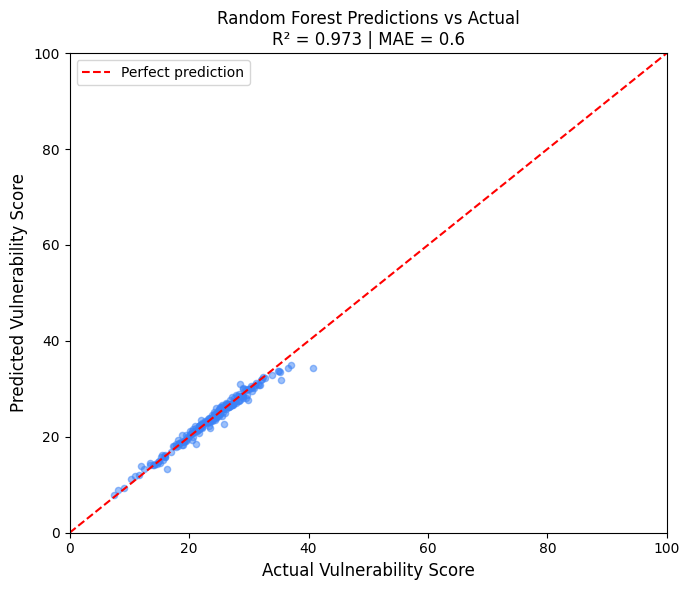

In [ ]:
# Train the model
print('Training Random Forest model...')

rf_model = RandomForestRegressor(
    n_estimators=200,   # Number of trees (more = more stable, slower to train)
    max_depth=8,        # Maximum depth of each tree (prevents overfitting)
    min_samples_leaf=5, # Each leaf must have at least 5 samples
    random_state=42,    # For reproducibility — always set this!
    n_jobs=-1           # Use all CPU cores for faster training
)

rf_model.fit(X_train, y_train)
print('Model trained')

# Evaluate on the test set
y_pred = rf_model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print()
print('=== MODEL EVALUATION (Test Set) ===')
print(f'R² Score:                  {r2:.4f}')
print(f'  -> Explains {r2*100:.1f}% of variance in vulnerability scores')
print(f'Mean Absolute Error (MAE): {mae:.2f} points')
print(f'  -> On average, predictions are off by {mae:.1f}/100 score points')

# Visualize predictions vs actuals
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.5, s=20, color='#3b82f6')
ax.plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Vulnerability Score', fontsize=12)
ax.set_ylabel('Predicted Vulnerability Score', fontsize=12)
ax.set_title(f'Random Forest Predictions vs Actual\nR² = {r2:.3f} | MAE = {mae:.1f}', fontsize=12)
ax.legend()
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('04_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 - Feature Importance: What Drives Flood Vulnerability?

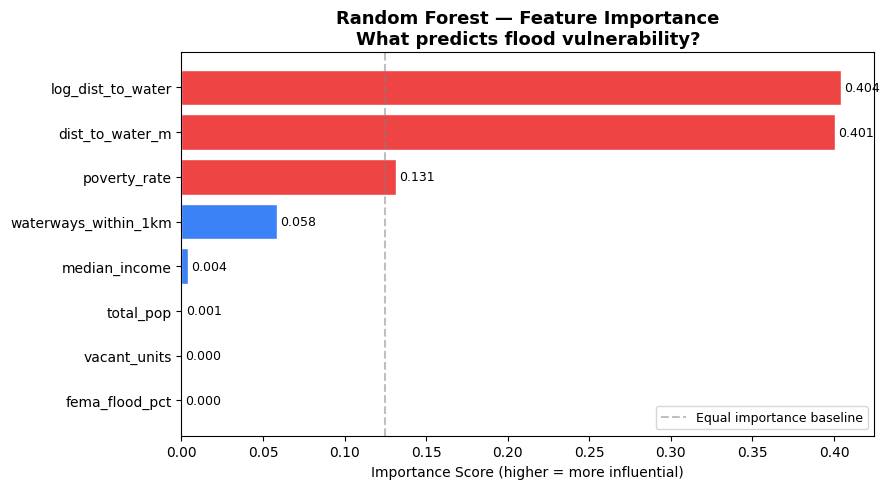


Top 3 most important features:
  log_dist_to_water         0.404
  dist_to_water_m           0.401
  poverty_rate              0.131


In [ ]:
# Feature Importance Plot
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#3b82f6' if i < len(feat_df)-3 else '#ef4444'
          for i in range(len(feat_df))]
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=colors, edgecolor='white')

# Add value labels on the bars
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Random Forest — Feature Importance\nWhat predicts flood vulnerability?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (higher = more influential)')
ax.axvline(x=1/len(FEATURE_COLS), color='gray', linestyle='--',
           alpha=0.5, label='Equal importance baseline')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 most important features:')
top3 = feat_df.nlargest(3, 'Importance')
for _, row in top3.iterrows():
    print(f'  {row["Feature"]:<25} {row["Importance"]:.3f}')


## 6. Build the Interactive Web Map

### 6.1 - Add ML Predictions Back to the GeoDataFrame

In [ ]:
# Add model predictions to the full clean dataset
# (We trained on a subset, now predict for ALL tracts)
X_all = tracts_clean[FEATURE_COLS].fillna(0).values
tracts_clean['predicted_score'] = rf_model.predict(X_all)
tracts_clean['predicted_score'] = tracts_clean['predicted_score'].clip(0, 100)

# Also assign a predicted risk tier label
tracts_clean['predicted_tier'] = pd.cut(
    tracts_clean['predicted_score'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['Very Low','Low','Medium','High','Very High']
)

print(tracts_clean['predicted_tier'].value_counts())


predicted_tier
Low          874
Very Low     236
Medium         0
High           0
Very High      0
Name: count, dtype: int64


### 6.2 - Build the Folim Choropleth Map

In [ ]:
# Convert to WGS84 (lat/lon) for web mapping — Folium needs EPSG:4326
tracts_web = tracts_clean.to_crs('EPSG:4326')

# Initialize the Folium map
# Center on Harris County, TX
m = folium.Map(
    location=[29.78, -95.37],
    zoom_start=10,
    tiles='CartoDB positron',   # Clean, minimal basemap
    attr='CartoDB'
)

# Add the vulnerability choropleth layer
choropleth = folium.Choropleth(
    geo_data=tracts_web.__geo_interface__,
    name='Flood Vulnerability Score',
    data=tracts_web,
    columns=['GEOID', 'predicted_score'],
    key_on='feature.properties.GEOID',
    fill_color='YlOrRd',         # Yellow → Orange → Red color ramp
    fill_opacity=0.75,
    line_opacity=0.3,
    line_weight=0.5,
    legend_name='Flood Vulnerability Score (0–100)',
    nan_fill_color='lightgray',
    highlight=True,              # Highlight tract on hover
).add_to(m)

# Add tooltip: hover over a tract to see details
tooltip_cols = ['GEOID', 'predicted_score', 'predicted_tier',
                'fema_flood_pct', 'poverty_rate', 'median_income',
                'total_pop', 'lisa_label']

# Round numerical columns for display
display_df = tracts_web.copy()
display_df['predicted_score'] = display_df['predicted_score'].round(1)
display_df['fema_flood_pct']  = (display_df['fema_flood_pct'] * 100).round(1)
display_df['poverty_rate']    = (display_df['poverty_rate'] * 100).round(1)
display_df['median_income']   = display_df['median_income'].apply(
    lambda x: f'${x:,.0f}' if pd.notna(x) else 'N/A'
)

folium.GeoJson(
    display_df.__geo_interface__,
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0},
    tooltip=folium.GeoJsonTooltip(
        fields=['predicted_score', 'predicted_tier', 'fema_flood_pct',
                'poverty_rate', 'median_income', 'total_pop', 'lisa_label'],
        aliases=['Vulnerability Score:', 'Risk Tier:',
                 'FEMA Flood Zone %:', 'Poverty Rate %:',
                 'Median Income:', 'Population:',
                 'Cluster Type:'],
        localize=True,
        sticky=False,
        style='font-family: Arial; font-size: 12px;'
    )
).add_to(m)

# Add LISA hotspot layer as a toggle
lisa_colors = {
    'HH (Hotspot)': '#dc2626',
    'LL (Coldspot)': '#3b82f6',
    'HL (Outlier)': '#93c5fd',
    'LH (Outlier)': '#f97316',
    'Not Significant': 'transparent'
}

folium.GeoJson(
    display_df.__geo_interface__,
    name='LISA Clusters (toggle)',
    style_function=lambda feature: {
        'fillColor': lisa_colors.get(feature['properties']['lisa_label'], 'gray'),
        'fillOpacity': 0.7 if feature['properties']['lisa_label'] != 'Not Significant' else 0,
        'weight': 0.5,
        'color': '#374151',
    },
    show=False,   # Hidden by default — user can toggle on
).add_to(m)

# Add layer control
folium.LayerControl(position='topright', collapsed=False).add_to(m)

# Save to HTML file
output_path = 'flood_vulnerability_harris_county.html'
m.save(output_path)
# print(f'Interactive map saved: {output_path}')
# print(f'   Open this file in any web browser to explore the map.')
# print(f'   Upload it to GitHub Pages to share it publicly.')
